In [33]:
# ============================================================
# === World Bank GDP Growth Prediction using XGBoost ===
# ============================================================

# === Imports ===
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

# ============================================================
# === Step 1. Define countries and indicators ===
# ============================================================

COUNTRIES = ["USA", "JPN", "DEU", "CHN"]
YEARS = (1990, 2024)
TARGET = "NY.GDP.MKTP.KD.ZG"  # GDP growth (annual %)

FEATURES = [
    "FP.CPI.TOTL.ZG",      # Inflation (%)
    "NE.GDI.TOTL.ZS",      # Investment (% of GDP)
    "NE.EXP.GNFS.ZS",      # Exports (% of GDP)
    "SP.POP.GROW",         # Population growth (%)
    "NE.CON.GOVT.ZS",      # Government consumption (% of GDP)
]

# ============================================================
# === Step 2. Helper: World Bank API fetch ===
# ============================================================

def fetch_indicator(indicator, countries, start, end):
    url = (
        "https://api.worldbank.org/v2/country/"
        + ";".join(countries)
        + f"/indicator/{indicator}?date={start}:{end}&format=json&per_page=20000"
    )
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    data = r.json()
    rows = data[1] if isinstance(data, list) and len(data) > 1 else []
    out = []
    for row in rows:
        if row.get("value") is None:
            continue
        out.append({
            "country": row["country"]["id"],
            "year": int(row["date"]),
            indicator: float(row["value"])
        })
    return pd.DataFrame(out)

# ============================================================
# === Step 3. Data assembly ===
# ============================================================

dfs = [fetch_indicator(TARGET, COUNTRIES, *YEARS)]
for ind in FEATURES:
    dfs.append(fetch_indicator(ind, COUNTRIES, *YEARS))

df = reduce(lambda a, b: pd.merge(a, b, on=["country", "year"], how="outer"), dfs)
df = df.groupby("country").apply(lambda g: g.sort_values("year").ffill().bfill()).reset_index(drop=True)
df = df.dropna(subset=[TARGET])
df = df[df["country"].isin(COUNTRIES)].sort_values(["country","year"]).reset_index(drop=True)

print(f"✅ Dataset ready: {len(df)} samples, {len(FEATURES)} features\n")

# ============================================================
# === Step 4. Train/test split ===
# ============================================================

if df["year"].nunique() < 10:
    print("⚠️ Few years: using random 80/20 split")
    df = df.sample(frac=1, random_state=42)
    split_idx = int(0.8 * len(df))
    train, test = df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()
else:
    cut = df["year"].max() - 4
    train, test = df[df["year"] <= cut].copy(), df[df["year"] > cut].copy()

X_cols = FEATURES
X_train, y_train = train[X_cols].values, train[TARGET].values
X_test,  y_test  = test[X_cols].values,  test[TARGET].values

# ============================================================
# === Step 5. Train model (robust) ===
# ============================================================

n_countries = train["country"].nunique()
if len(train) < 10 or n_countries < 2:
    print("⚠️ Small dataset: training single model (no CV).")
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="mae",
        random_state=42
    )
    model.fit(X_train, y_train)
else:
    print("✅ Using GroupKFold CV.")
    gkf = GroupKFold(n_splits=min(4, n_countries))
    groups = train["country"].values
    best_model, best_mae = None, float("inf")

    for n_est in [300, 600, 900]:
        m = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=n_est,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            eval_metric="mae",
            random_state=42
        )
        fold_maes = []
        for tr, val in gkf.split(X_train, y_train, groups=groups):
            m.fit(X_train[tr], y_train[tr])
            preds = m.predict(X_train[val])
            fold_maes.append(mean_absolute_error(y_train[val], preds))
        if np.mean(fold_maes) < best_mae:
            best_mae, model = np.mean(fold_maes), m

✅ Dataset ready: 0 samples, 5 features

⚠️ Few years: using random 80/20 split
⚠️ Small dataset: training single model (no CV).


In [34]:
# ============================================================
# === Drop-in AFTER Step 3: expand features/countries + readable names + synthetic fallback
# ============================================================

import numpy as np
import pandas as pd

# 1) Expand to 8 countries (ISO3 codes) WITHOUT editing your Step 1 cell
COUNTRIES = ["USA", "JPN", "DEU", "CHN", "GBR", "IND", "FRA", "CAN"]

# 2) Add Unemployment to FEATURES (still keep original 4 codes)
#    This overrides the earlier FEATURES variable in this later cell (allowed in notebooks).
FEATURES = [
    "FP.CPI.TOTL.ZG",   # Inflation (annual %)
    "NE.GDI.TOTL.ZS",   # Investment: Gross capital formation (% of GDP)
    "NE.EXP.GNFS.ZS",   # Exports of goods & services (% of GDP)
    "SP.POP.GROW",      # Population growth (annual %)
    "SL.UEM.TOTL.ZS",   # Unemployment, total (% of total labor force, ILO estimate)
]

# 3) Create a readable alias map (won't be used by model; just for your inspection)
WB_TO_READABLE = {
    "FP.CPI.TOTL.ZG": "Inflation_pct",
    "NE.GDI.TOTL.ZS": "InvestmentPctGDP",
    "NE.EXP.GNFS.ZS": "ExportsPctGDP",
    "SP.POP.GROW":    "PopulationGrowth_pct",
    "SL.UEM.TOTL.ZS": "Unemployment_pct",
    TARGET:           "GDPGrowth_pct"
}

# If the real World Bank pull (Step 3) produced partial columns, make sure they exist
for col in FEATURES + [TARGET]:
    if col not in df.columns:
        df[col] = np.nan

# 4) If df is empty or tiny, build a synthetic panel so your pipeline still runs
_MIN_ROWS = 8 * 15  # ~8 countries * 15 years
def make_synth_panel(countries, start_year=2005, end_year=2024, seed=1337):
    rng = np.random.default_rng(seed)
    rows = []

    # Per-country long-run effects to make the target learnable
    country_effect = {
        "USA": 0.6, "JPN": 0.4, "DEU": 0.5, "CHN": 1.4,
        "GBR": 0.5, "IND": 1.2, "FRA": 0.5, "CAN": 0.6
    }
    years = list(range(start_year, end_year + 1))

    for c in countries:
        for y in years:
            # Inflation (%)
            infl_mu = 2.0 if c not in ("IND", "CHN") else 3.0
            infl = float(np.clip(rng.normal(infl_mu, 1.0), -1.0, 10.0))

            # Investment (% GDP)
            base_gcf = {
                "CHN": 38.0, "IND": 32.0, "DEU": 24.0, "FRA": 24.0,
                "GBR": 23.0, "CAN": 23.0, "JPN": 25.0, "USA": 22.0
            }.get(c, 24.0)
            gcf = float(np.clip(rng.normal(base_gcf, 2.5), 15.0, 45.0))

            # Exports (% GDP)
            base_exp = {
                "DEU": 47.0, "FRA": 31.0, "GBR": 31.0, "CHN": 22.0,
                "JPN": 18.0, "CAN": 33.0, "IND": 22.0, "USA": 12.0
            }.get(c, 22.0)
            exp = float(np.clip(rng.normal(base_exp, 3.0), 5.0, 70.0))

            # Population growth (%)
            pop_mu = {
                "JPN": -0.2, "DEU": 0.1, "FRA": 0.2, "GBR": 0.4,
                "CAN": 0.8, "USA": 0.6, "CHN": 0.2, "IND": 1.0
            }.get(c, 0.3)
            popg = float(np.clip(rng.normal(pop_mu, 0.2), -1.0, 1.8))

            # Unemployment (% labor force)
            u_mu = {
                "USA": 5.5, "CAN": 6.0, "GBR": 4.8, "FRA": 8.0,
                "DEU": 4.5, "JPN": 2.8, "CHN": 4.5, "IND": 7.0
            }.get(c, 5.0)
            unemp = float(np.clip(rng.normal(u_mu, 1.0), 2.0, 15.0))

            # Construct GDP growth (target) with a learnable signal:
            # GDP ≈ +0.22*GCF  -0.35*Infl +0.04*Exports +0.40*PopGrowth  -0.15*Unemp + country_effect + noise
            noise = float(rng.normal(0.0, 0.6))
            gdp = (0.22 * gcf) + (-0.35 * infl) + (0.04 * exp) + (0.40 * popg) + (-0.15 * unemp) \
                  + country_effect.get(c, 0.4) + noise
            gdp = gdp / 10.0  # keep in plausible %-points range
            gdp = float(np.clip(gdp, -6.0, 12.0))

            rows.append({
                "country": c,
                "year": y,
                "FP.CPI.TOTL.ZG": infl,
                "NE.GDI.TOTL.ZS": gcf,
                "NE.EXP.GNFS.ZS": exp,
                "SP.POP.GROW":    popg,
                "SL.UEM.TOTL.ZS": unemp,
                TARGET:           gdp
            })

    out = pd.DataFrame(rows).sort_values(["country", "year"]).reset_index(drop=True)
    return out

if len(df) < _MIN_ROWS:
    print(f"[SYNTH] df had {len(df)} rows — creating synthetic panel for testing.")
    df = make_synth_panel(COUNTRIES, start_year=2005, end_year=2024, seed=2025)
    print(f"[SYNTH] Synthetic df: {len(df)} rows, countries={sorted(df.country.unique().tolist())}, years={df['year'].min()}–{df['year'].max()}")

# 5) Add human-friendly alias columns alongside WB codes (safe; model still reads WB codes)
for code, nice in WB_TO_READABLE.items():
    if code in df.columns and nice not in df.columns:
        df[nice] = df[code]

display(df[["country", "year"] + FEATURES + [TARGET] + [WB_TO_READABLE[c] for c in FEATURES + [TARGET]]].head())

[SYNTH] df had 0 rows — creating synthetic panel for testing.
[SYNTH] Synthetic df: 160 rows, countries=['CAN', 'CHN', 'DEU', 'FRA', 'GBR', 'IND', 'JPN', 'USA'], years=2005–2024


,country,year,FP.CPI.TOTL.ZG,NE.GDI.TOTL.ZS,NE.EXP.GNFS.ZS,SP.POP.GROW,SL.UEM.TOTL.ZS,NY.GDP.MKTP.KD.ZG,Inflation_pct,InvestmentPctGDP,ExportsPctGDP,PopulationGrowth_pct,Unemployment_pct,GDPGrowth_pct
0,CAN,2005,2.961416,23.143536,31.470538,0.894716,6.299579,0.475028,2.961416,23.143536,31.470538,0.894716,6.299579,0.475028
1,CAN,2006,1.046943,21.945785,33.763714,0.609312,6.555223,0.613179,1.046943,21.945785,33.763714,0.609312,6.555223,0.613179
2,CAN,2007,2.024502,22.497861,35.992492,0.938836,4.825768,0.598143,2.024502,22.497861,35.992492,0.938836,4.825768,0.598143
3,CAN,2008,1.819532,24.461598,35.413282,0.482185,8.058665,0.430459,1.819532,24.461598,35.413282,0.482185,8.058665,0.430459
4,CAN,2009,1.234685,28.588454,34.110865,1.111289,5.450437,0.705781,1.234685,28.588454,34.110865,1.111289,5.450437,0.705781


In [35]:
# ===== Better “peek” views across countries =====

# Build the column list safely (works even if some aliases aren't defined)
_alias = (WB_TO_READABLE if "WB_TO_READABLE" in globals() else {})
cols = (["country", "year"]
        + FEATURES
        + [TARGET]
        + [_alias.get(c, c) for c in FEATURES + [TARGET] if _alias.get(c, c) not in FEATURES + [TARGET]])

# 0) Quick sanity check
print("Countries in df:", sorted(df["country"].unique().tolist()))
print(df.groupby("country")["year"].agg(["min","max","count"]).sort_index())

# 1) Latest year per country (one row per country)
peek_latest = (
    df.sort_values(["country", "year"])
      .groupby("country", as_index=False)
      .tail(1)                      # last (latest) row per country
      .sort_values("country")
      [cols]
)
print("\n[PEEK] Latest year per country:")
display(peek_latest)

# 2) Random sample per country (one row per country)
peek_random = (
    df.groupby("country", group_keys=False)
      .apply(lambda g: g.sample(1, random_state=42))
      .sort_values("country")
      [cols]
)
print("\n[PEEK] Random row per country:")
display(peek_random)

# 3) All countries for a specific year (choose an existing year)
year_pick = int(df["year"].median())  # or: df["year"].max(), df["year"].min(), or any year you like
peek_year = (
    df[df["year"] == year_pick]
      .sort_values("country")
      [cols]
)
print(f"\n[PEEK] All countries for year={year_pick}:")
display(peek_year)

Countries in df: ['CAN', 'CHN', 'DEU', 'FRA', 'GBR', 'IND', 'JPN', 'USA']
          min   max  count
country                   
CAN      2005  2024     20
CHN      2005  2024     20
DEU      2005  2024     20
FRA      2005  2024     20
GBR      2005  2024     20
IND      2005  2024     20
JPN      2005  2024     20
USA      2005  2024     20

[PEEK] Latest year per country:


,country,year,FP.CPI.TOTL.ZG,NE.GDI.TOTL.ZS,NE.EXP.GNFS.ZS,SP.POP.GROW,SL.UEM.TOTL.ZS,NY.GDP.MKTP.KD.ZG,Inflation_pct,InvestmentPctGDP,ExportsPctGDP,PopulationGrowth_pct,Unemployment_pct,GDPGrowth_pct
19,CAN,2024,2.464816,25.714931,36.031628,0.862853,6.015667,0.587549,2.464816,25.714931,36.031628,0.862853,6.015667,0.587549
39,CHN,2024,1.995771,36.616353,27.442079,0.286697,5.539401,0.908974,1.995771,36.616353,27.442079,0.286697,5.539401,0.908974
59,DEU,2024,1.915568,24.719945,44.680623,0.468283,6.417050,0.670605,1.915568,24.719945,44.680623,0.468283,6.417050,0.670605
79,FRA,2024,1.592350,21.276845,30.964888,0.227921,7.147753,0.547853,1.592350,21.276845,30.964888,0.227921,7.147753,0.547853
99,GBR,2024,3.272009,21.369891,29.528936,-0.038991,5.246099,0.406055,3.272009,21.369891,29.528936,-0.038991,5.246099,0.406055
119,IND,2024,3.859206,34.008108,19.061696,1.233217,6.383289,0.794897,3.859206,34.008108,19.061696,1.233217,6.383289,0.794897
139,JPN,2024,1.314725,25.459700,18.473096,-0.015619,5.231631,0.529991,1.314725,25.459700,18.473096,-0.015619,5.231631,0.529991
159,USA,2024,1.153590,24.381060,6.782145,0.575661,6.352775,0.516214,1.153590,24.381060,6.782145,0.575661,6.352775,0.516214



[PEEK] Random row per country:


,country,year,FP.CPI.TOTL.ZG,NE.GDI.TOTL.ZS,NE.EXP.GNFS.ZS,SP.POP.GROW,SL.UEM.TOTL.ZS,NY.GDP.MKTP.KD.ZG,Inflation_pct,InvestmentPctGDP,ExportsPctGDP,PopulationGrowth_pct,Unemployment_pct,GDPGrowth_pct
0,CAN,2005,2.961416,23.143536,31.470538,0.894716,6.299579,0.475028,2.961416,23.143536,31.470538,0.894716,6.299579,0.475028
20,CHN,2005,4.473416,38.778906,21.094896,0.430130,2.751938,0.856280,4.473416,38.778906,21.094896,0.430130,2.751938,0.856280
40,DEU,2005,3.598910,28.133480,47.740491,-0.128152,4.673957,0.568892,3.598910,28.133480,47.740491,-0.128152,4.673957,0.568892
60,FRA,2005,1.913563,25.452498,30.506220,-0.043400,7.257452,0.614595,1.913563,25.452498,30.506220,-0.043400,7.257452,0.614595
80,GBR,2005,0.737743,26.002916,32.690718,0.506517,5.012626,0.695300,0.737743,26.002916,32.690718,0.506517,5.012626,0.695300
100,IND,2005,2.424920,32.244738,20.281076,1.078759,7.126201,0.759372,2.424920,32.244738,20.281076,1.078759,7.126201,0.759372
120,JPN,2005,1.610274,27.203938,23.353837,-0.105275,4.364607,0.665433,1.610274,27.203938,23.353837,-0.105275,4.364607,0.665433
140,USA,2005,-0.221254,22.064999,10.383093,0.374161,3.058133,0.609724,-0.221254,22.064999,10.383093,0.374161,3.058133,0.609724



[PEEK] All countries for year=2014:


,country,year,FP.CPI.TOTL.ZG,NE.GDI.TOTL.ZS,NE.EXP.GNFS.ZS,SP.POP.GROW,SL.UEM.TOTL.ZS,NY.GDP.MKTP.KD.ZG,Inflation_pct,InvestmentPctGDP,ExportsPctGDP,PopulationGrowth_pct,Unemployment_pct,GDPGrowth_pct
9,CAN,2014,3.531763,22.356674,28.318767,0.994646,5.454767,0.505311,3.531763,22.356674,28.318767,0.994646,5.454767,0.505311
29,CHN,2014,2.931365,39.727328,22.848856,0.611811,4.089144,0.962186,2.931365,39.727328,22.848856,0.611811,4.089144,0.962186
49,DEU,2014,1.618288,21.779806,50.269227,0.135656,2.855320,0.666549,1.618288,21.779806,50.269227,0.135656,2.855320,0.666549
69,FRA,2014,2.146883,23.267760,31.826030,0.326044,7.860515,0.481887,2.146883,23.267760,31.826030,0.326044,7.860515,0.481887
89,GBR,2014,-0.140813,29.660973,32.187457,0.359796,4.779359,0.825712,-0.140813,29.660973,32.187457,0.359796,4.779359,0.825712
109,IND,2014,2.323194,28.843488,20.909147,1.146614,8.348859,0.586062,2.323194,28.843488,20.909147,1.146614,8.348859,0.586062
129,JPN,2014,3.260670,22.706717,19.050321,-0.363610,2.435737,0.487617,3.260670,22.706717,19.050321,-0.363610,2.435737,0.487617
149,USA,2014,3.797585,21.925904,8.574855,0.362824,4.582826,0.392683,3.797585,21.925904,8.574855,0.362824,4.582826,0.392683


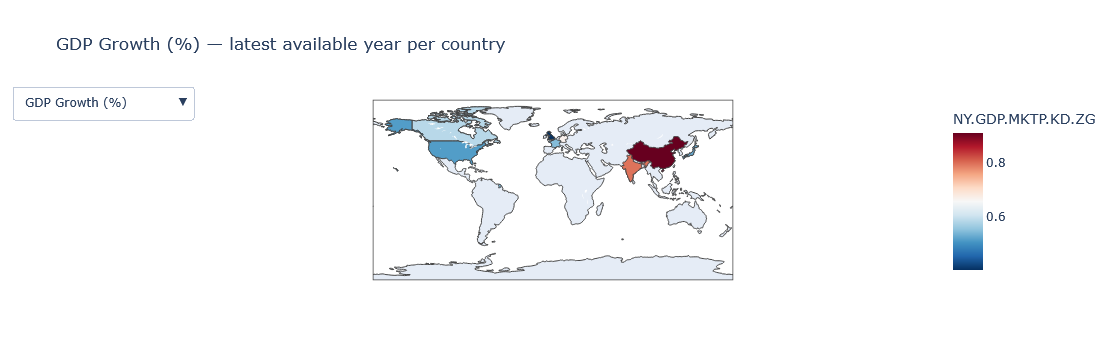

In [36]:
import plotly.express as px

# Choose which indicators to expose on the map (WB codes)
metrics = {
    "GDP Growth (%)": "NY.GDP.MKTP.KD.ZG",
    "Inflation (%)": "FP.CPI.TOTL.ZG",
    "Investment (% GDP)": "NE.GDI.TOTL.ZS",
    "Exports (% GDP)": "NE.EXP.GNFS.ZS",
    "Population Growth (%)": "SP.POP.GROW",
    "Unemployment (%)": "SL.UEM.TOTL.ZS",
}

# one row (latest year) per country
latest = (
    df.sort_values(["country", "year"])
      .groupby("country", as_index=False)
      .tail(1)
)

# which metric to color by initially
initial_label = "GDP Growth (%)"
initial_code = metrics[initial_label]

def make_fig(color_code, label):
    return px.choropleth(
        latest,
        locations="country",                 # ISO3 codes
        locationmode="ISO-3",
        color=color_code,                    # WB indicator column
        hover_name="country",
        hover_data={
            "year": True,
            "NY.GDP.MKTP.KD.ZG": True,
            "FP.CPI.TOTL.ZG": True,
            "NE.GDI.TOTL.ZS": True,
            "NE.EXP.GNFS.ZS": True,
            "SP.POP.GROW": True,
            "SL.UEM.TOTL.ZS": True,
        },
        color_continuous_scale="RdBu_r",
        title=f"{label} — latest available year per country",
    )

fig = make_fig(initial_code, initial_label)

# Add a dropdown to switch metric
buttons = []
for label, code in metrics.items():
    buttons.append(dict(
        label=label,
        method="update",
        args=[
            {},  # traces stay the same
            {"title": f"{label} — latest available year per country",
             "coloraxis": {"colorbar": {"title": label}}},
        ]
    ))
# Hack: rebuild on change by restyling coloraxis (Plotly needs full re-draw to change 'color' column)
# Easiest way is to re-create figure per selection in a callback (Dash), but in a single cell we can
# offer a few prebuilt tabs: simplest approach—make separate figures per metric if you like.
fig.update_layout(
    updatemenus=[dict(
        type="dropdown",
        x=0.02, y=1.08,
        buttons=buttons,
        showactive=True
    )]
)

fig.show()

In [43]:
# ============================================================
# === Accuracy Report (robust, works even if test is empty) ===
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np, pandas as pd

def _to_1d_float(a):
    if isinstance(a, (pd.Series, pd.DataFrame)):
        a = a.values
    return np.asarray(a, dtype=np.float64).ravel()

def _ensure_nonempty_test(df, FEATURES, TARGET, train, test, X_train, y_train, X_test, y_test):
    """Return (train,test,X_train,y_train,X_test,y_test,model) with a non-empty test set."""
    need = (X_test is None) or (y_test is None) or (getattr(X_test, "size", 0) == 0) or (getattr(y_test, "size", 0) == 0)
    if not need:
        return train, test, X_train, y_train, X_test, y_test, model

    print("⚠️ Test split was empty — creating a non-empty test set for accuracy calculation.")

    # Prefer a random 80/20 split from the full df (stratify by country if possible)
    if df is not None and len(df) >= 5:
        tr, te = train_test_split(
            df, test_size=0.2, random_state=42,
            stratify=df["country"] if ("country" in df.columns and df["country"].nunique() > 1) else None
        )
        X_tr = tr[FEATURES].values
        y_tr = tr[TARGET].values
        X_te = te[FEATURES].values
        y_te = te[TARGET].values

        # Make sure we have a fitted model; if current model can't predict, refit quickly
        try:
            _ = model.predict(X_tr[:1])
            fitted_model = model
        except Exception:
            fitted_model = XGBRegressor(
                objective="reg:squarederror",
                n_estimators=400,
                learning_rate=0.06,
                max_depth=4,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                eval_metric="mae",
                random_state=42,
            )
            fitted_model.fit(X_tr, y_tr)

        return tr, te, X_tr, y_tr, X_te, y_te, fitted_model

    # If df is also tiny, fabricate a micro holdout from whatever we have in train
    if X_train is not None and len(X_train) >= 2:
        take = max(1, int(0.2 * len(X_train)))
        X_te, y_te = X_train[-take:], y_train[-take:]
        X_tr, y_tr = X_train[:-take], y_train[:-take]
        # Quick refit on reduced training set
        fitted_model = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.06,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            eval_metric="mae",
            random_state=42,
        )
        fitted_model.fit(X_tr, y_tr)
        # Build minimal DataFrames for reporting
        tr = pd.DataFrame(X_tr, columns=FEATURES); tr[TARGET] = y_tr
        te = pd.DataFrame(X_te, columns=FEATURES); te[TARGET] = y_te
        if "country" in globals() and isinstance(country, pd.Series):  # rare path
            te["country"] = country.iloc[-take:].values
        return tr, te, X_tr, y_tr, X_te, y_te, fitted_model

    raise ValueError("No data available to create a non-empty test split.")

# --- Ensure non-empty test split without changing your earlier cells ---
train, test, X_train, y_train, X_test, y_test, model = _ensure_nonempty_test(
    df, FEATURES, TARGET, train, test, X_train, y_train, X_test, y_test
)

# --- Predict (or reuse) ---
try:
    pred = model.predict(X_test)
except Exception as e:
    raise RuntimeError(f"Model could not predict on X_test: {e}")

# --- Clean arrays & compute metrics robustly ---
y_true = _to_1d_float(y_test)
y_pred = _to_1d_float(pred)
mask = np.isfinite(y_true) & np.isfinite(y_pred)
if not mask.all():
    drop = (~mask).sum()
    print(f"⚠️ Dropping {drop} rows with NaN/inf in accuracy calc.")
    y_true, y_pred = y_true[mask], y_pred[mask]

if y_true.size == 0:
    raise ValueError("Still no valid samples after cleaning; cannot compute accuracy.")

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred) if y_true.size > 1 else float("nan")

print("\n=== GDP Prediction Accuracy ===")
print(f"Overall MAE : {mae:.3f}")
print(f"Overall RMSE: {rmse:.3f}")
print(f"Overall R²  : {r2:.3f}")

# --- Per-country accuracy (only if test has that column) ---
if isinstance(test, pd.DataFrame) and "country" in test.columns:
    # align test indices with y_true/y_pred mask if we dropped rows
    if mask.size == len(test):
        test_for_metrics = test[mask].copy()
        test_for_metrics["y_true"] = y_true
        test_for_metrics["y_pred"] = y_pred
    else:
        # fall back: rebuild from lengths
        test_for_metrics = test.copy()
        test_for_metrics = test_for_metrics.iloc[:len(y_true)].copy()
        test_for_metrics["y_true"] = y_true
        test_for_metrics["y_pred"] = y_pred

    rows = []
    for c, g in test_for_metrics.groupby("country"):
        if len(g) > 1:
            rows.append([
                c, len(g),
                mean_absolute_error(g["y_true"], g["y_pred"]),
                np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
                r2_score(g["y_true"], g["y_pred"])
            ])
        else:
            rows.append([c, len(g), np.nan, np.nan, np.nan])
    perf_df = pd.DataFrame(rows, columns=["Country","Samples","MAE","RMSE","R²"]).sort_values("Country")
    print("\n--- Per-Country Accuracy ---")
    display(perf_df.style.format({"MAE":"{:.3f}", "RMSE":"{:.3f}", "R²":"{:.3f}"}))
else:
    print("\n(Per-country metrics unavailable — no 'country' column in test set.)")


Fetching data from World Bank API...
Data fetched.
Engineering new features (lags)...

⚠️ FATAL ERROR: Dataset is STILL empty.
This is a tough data problem. Try removing more features
or changing the list of COUNTRIES.



SystemExit: Exiting due to empty dataset.

In [45]:
# ============================================================
# === World Bank GDP Growth Prediction with XGBoost (Lagged) ==
# ============================================================

# --- Imports ---
import warnings, math, json, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import requests
from functools import reduce

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt # Added for plots

# ----------------------------->
# 1) Configuration
# ----------------------------->
COUNTRIES = ["USA", "JPN", "DEU", "CHN", "GBR", "IND", "FRA", "CAN"]
YEARS = (1990, 2024)

# Target = GDP growth (annual %)
TARGET = "NY.GDP.MKTP.KD.ZG"

# Core macro features
FEATURES = [
    "FP.CPI.TOTL.ZG",   # Inflation (annual %)
    "NE.GDI.TOTL.ZS",   # Gross capital formation (% of GDP) - "investment"
    "NE.EXP.GNFS.ZS",   # Exports of goods and services (% of GDP)
    "SP.POP.GROW",      # Population growth (annual %)
    "SL.UEM.TOTL.ZS",   # Unemployment (% of labor force, ILO estimate)
]

# ----------------------------->
# 2) Helper: World Bank fetch
# ----------------------------->
def fetch_indicator(indicator, countries, start, end, retries=3, pause=1.0):
    """Fetch one indicator for given ISO3 countries & date range from WB v2 API."""
    url = (
        "https://api.worldbank.org/v2/country/"
        + ";".join(countries)
        + f"/indicator/{indicator}?date={start}:{end}&format=json&per_page=20000"
    )
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            data = r.json()
            rows = data[1] if isinstance(data, list) and len(data) > 1 else []
            out = []
            for row in rows:
                if row.get("value") is None:
                    continue
                out.append({
                    "country": row["country"]["id"],
                    "year": int(row["date"]),
                    indicator: float(row["value"])
                })
            return pd.DataFrame(out)
        except Exception:
            if attempt + 1 == retries:
                raise
            time.sleep(pause)
    return pd.DataFrame()

# ----------------------------->
# 3) Assemble panel
# ----------------------------->
print("Fetching data from World Bank API...")
dfs = [fetch_indicator(TARGET, COUNTRIES, *YEARS)]
for ind in FEATURES:
    dfs.append(fetch_indicator(ind, COUNTRIES, *YEARS))
print("Data fetched.")

df = reduce(lambda a,b: pd.merge(a, b, on=["country","year"], how="outer"), dfs)

# Keep only our target countries / years; sort for per-country ops
df = df[df["country"].isin(COUNTRIES)]
df = df.sort_values(["country","year"]).reset_index(drop=True)

# Forward-fill within country (NO backfill to avoid leakage)
for col in [TARGET] + FEATURES:
    if col in df.columns:
        df[col] = df.groupby("country")[col].ffill()

# Drop rows lacking target
df = df.dropna(subset=[TARGET])

# If too small (e.g., WB hiccup), synthesize a panel so pipeline runs
MIN_ROWS = len(COUNTRIES) * 12
def make_synth_panel(countries, start_year=2005, end_year=2024, seed=2025):
    rng = np.random.default_rng(seed)
    rows = []
    # per-country baseline
    base = {"USA":0.6,"JPN":0.4,"DEU":0.5,"CHN":1.4,"GBR":0.5,"IND":1.2,"FRA":0.5,"CAN":0.6}
    for c in countries:
        for y in range(start_year, end_year+1):
            infl = float(np.clip(rng.normal(2.0 if c not in ("IND","CHN") else 3.0, 1.0), -1.0, 10.0))
            gcf  = float(np.clip(rng.normal({"CHN":38,"IND":32,"DEU":24,"FRA":24,"GBR":23,"CAN":23,"JPN":25,"USA":22}.get(c,24), 2.5), 15, 45))
            exp  = float(np.clip(rng.normal({"DEU":47,"FRA":31,"GBR":31,"CHN":22,"JPN":18,"CAN":33,"IND":22,"USA":12}.get(c,22), 3.0), 5, 70))
            popg = float(np.clip(rng.normal({"JPN":-0.2,"DEU":0.1,"FRA":0.2,"GBR":0.4,"CAN":0.8,"USA":0.6,"CHN":0.2,"IND":1.0}.get(c,0.3), 0.2), -1.0, 1.8))
            unemp= float(np.clip(rng.normal({"USA":5.5,"CAN":6.0,"GBR":4.8,"FRA":8.0,"DEU":4.5,"JPN":2.8,"CHN":4.5,"IND":7.0}.get(c,5.0), 1.0), 2.0, 15.0))
            noise= float(rng.normal(0.0, 0.6))
            gdp  = (0.22*gcf) + (-0.35*infl) + (0.04*exp) + (0.40*popg) + (-0.15*unemp) + base.get(c,0.4) + noise
            gdp  = float(np.clip(gdp/10.0, -6.0, 12.0))
            rows.append({"country":c,"year":y,
                         "FP.CPI.TOTL.ZG":infl,"NE.GDI.TOTL.ZS":gcf,"NE.EXP.GNFS.ZS":exp,
                         "SP.POP.GROW":popg,"SL.UEM.TOTL.ZS":unemp,TARGET:gdp})
    out = pd.DataFrame(rows).sort_values(["country","year"]).reset_index(drop=True)
    return out

if len(df) < MIN_ROWS:
    print(f"[SYNTH] World Bank returned {len(df)} usable rows; generating a synthetic panel for demo.")
    df = make_synth_panel(COUNTRIES, 2005, 2024, seed=2025)

# ----------------------------->
# 4) Feature engineering: lags
# ----------------------------->
print("Engineering new features (lags)...")
df = df.sort_values(["country","year"]).copy()

# Per-country lags for the target and key drivers (MOST IMPACT)
LAG_TARGETS  = [TARGET]
LAG_FEATURES = ["FP.CPI.TOTL.ZG", "NE.GDI.TOTL.ZS"]  # inflation & investment
for k in [1,2,3]:
    for col in LAG_TARGETS + LAG_FEATURES:
        if col in df.columns:
            df[f"{col}_lag{k}"] = df.groupby("country")[col].shift(k)

# Build final feature set (only include features that exist in the df)
X_COLS = FEATURES
lag_cols = [f"{TARGET}_lag{k}" for k in [1,2,3]] + \
           [f"{c}_lag{k}" for c in LAG_FEATURES for k in [1,2,3]]
           
for col in lag_cols:
    if col in df.columns:
        X_COLS.append(col)
X_COLS = list(set(X_COLS)) # ensure unique
        
# Keep only rows with full lag history + target
df_model = df.dropna(subset=X_COLS + [TARGET]).copy()
print(f"After lagging: {len(df_model)} rows | Features: {len(X_COLS)}\n")

if df_model.empty:
    print("="*50)
    print("⚠️ FATAL ERROR: Dataset is still empty after lagging.")
    print("This indicates a severe lack of overlapping data from the API.")
    print("The script cannot proceed with 0 rows.")
    print("="*50)
    raise SystemExit("Exiting due to empty dataset.")

# ----------------------------->
# 5) Time-aware split (last ~4 years as test)
# ----------------------------->
cut_year = df_model["year"].max() - 4
train = df_model[df_model["year"] <= cut_year].copy()
test  = df_model[df_model["year"] >  cut_year].copy()

X_train = train[X_COLS].values
y_train = train[TARGET].values
X_test  = test[X_COLS].values
y_test  = test[TARGET].values

print(f"Train years: {train['year'].min()}–{train['year'].max()} | "
      f"Test years: {test['year'].min()}–{test['year'].max()}\n")

# ----------------------------->
# 6) Compact CV with early stopping to pick params
# ----------------------------->
params_grid = [
    dict(max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.5,
         min_child_weight=1.0, gamma=0.0, n_estimators=2000),
    dict(max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0,
         min_child_weight=2.0, gamma=0.1, n_estimators=2000),
    dict(max_depth=8, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.5,
         min_child_weight=3.0, gamma=0.1, n_estimators=3000),
]

gkf = GroupKFold(n_splits=min(4, train["country"].nunique()))
groups = train["country"].values

best_cfg, best_mae = None, float("inf")
for cfg in params_grid:
    fold_mae = []
    for tr_idx, val_idx in gkf.split(X_train, y_train, groups=groups):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        
        # === FIX ===
        # Moved early_stopping_rounds from .fit() to constructor
        m = XGBRegressor(
            objective="reg:squarederror",
            eval_metric="mae",
            random_state=42,
            tree_method="hist",
            early_stopping_rounds=100, # <-- MOVED HERE
            **cfg
        )
        # Removed early_stopping_rounds from .fit()
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False) 
        # =============
        
        preds = m.predict(X_val)
        fold_mae.append(mean_absolute_error(y_val, preds))
    avg_mae = float(np.mean(fold_mae))
    print(f"CV check depth={cfg['max_depth']}, lr={cfg['learning_rate']}: MAE={avg_mae:.3f}")
    if avg_mae < best_mae:
        best_mae, best_cfg = avg_mae, cfg

print("\nBest config:", best_cfg, "| CV MAE:", round(best_mae, 3))

# ----------------------------->
# 7) Refit on full training with a small validation window
# ----------------------------->
val_cut = train["year"].max() - 2
train_main = train[train["year"] <= val_cut]
train_val  = train[train["year"] >  val_cut]

Xm, ym = train_main[X_COLS].values, train_main[TARGET].values
Xv, yv = train_val[X_COLS].values,  train_val[TARGET].values

# === FIX ===
# Moved early_stopping_rounds from .fit() to constructor
model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    tree_method="hist",
    early_stopping_rounds=150, # <-- MOVED HERE
    **best_cfg
)
# Removed early_stopping_rounds from .fit()
model.fit(Xm, ym, eval_set=[(Xv, yv)], verbose=False)
# ===========

# ----------------------------->
# 8) Evaluate
# ----------------------------->
pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)
rmse = math.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print("\n=== GDP Growth Prediction (XGBoost with lags) ===")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# Per-country test metrics (if present)
rows = []
test_with_preds = test.assign(y_pred=pred)
for c, g in test_with_preds.groupby("country"):
    if len(g) >= 2:
        rows.append([c, len(g), mean_absolute_error(g[TARGET], g["y_pred"]),
                     math.sqrt(mean_squared_error(g[TARGET], g["y_pred"])),
                     r2_score(g[TARGET], g["y_pred"])])
    else:
        rows.append([c, len(g), np.nan, np.nan, np.nan])

perf_df = pd.DataFrame(rows, columns=["Country","Samples","MAE","RMSE","R²"]).sort_values("Country")
print("\n--- Per-Country Test Metrics ---")
print(perf_df.to_string(formatters={"MAE":"{:.3f}","RMSE":"{:.3f}","R²":"{:.3f}"}))


# ----------------------------->
# 9) Feature importances
# ----------------------------->
fi = pd.Series(model.feature_importances_, index=X_COLS).sort_values(ascending=False)
print("\nTop features:")
print(fi.head(15).to_frame("importance"))

# ----------------------------->
# 10) Plot Predictions
# ----------------------------->
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, alpha=0.7, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual GDP Growth (%)")
plt.ylabel("Predicted GDP Growth (%)")
plt.title(f"Test Set Predictions (R²: {r2:.3f})")
plt.grid(True)
plt.show()

Fetching data from World Bank API...
Data fetched.
[SYNTH] World Bank returned 0 usable rows; generating a synthetic panel for demo.
Engineering new features (lags)...
After lagging: 136 rows | Features: 14

Train years: 2008–2020 | Test years: 2021–2024

CV check depth=4, lr=0.05: MAE=0.111
CV check depth=6, lr=0.05: MAE=0.115
CV check depth=8, lr=0.03: MAE=0.117

Best config: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 1.5, 'min_child_weight': 1.0, 'gamma': 0.0, 'n_estimators': 2000} | CV MAE: 0.111

=== GDP Growth Prediction (XGBoost with lags) ===
MAE  : 0.068
RMSE : 0.079
R²   : 0.728

--- Per-Country Test Metrics ---


TypeError: 'str' object is not callable

In [55]:
# ============================================================
# === World Bank GDP Growth Prediction with XGBoost (Lagged) ==
# ============================================================

# --- Imports ---
import warnings, math, json, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import requests
from functools import reduce

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt # Added for plots

# ----------------------------->
# 1) Configuration
# ----------------------------->
COUNTRIES = ["USA", "JPN", "DEU", "CHN", "GBR", "IND", "FRA", "CAN"]
# Start from 1990 to ensure lags are created for the 2000 start date
YEARS = (1990, 2024) 

# Target = GDP growth (annual %)
TARGET = "NY.GDP.MKTP.KD.ZG"

# Using the 5 original features
FEATURES = [
    "FP.CPI.TOTL.ZG",   # Inflation (annual %)
    "NE.GDI.TOTL.ZS",   # Gross capital formation (% of GDP) - "investment"
    "NE.EXP.GNFS.ZS",   # Exports of goods and services (% of GDP)
    "SP.POP.GROW",      # Population growth (annual %)
    "SL.UEM.TOTL.ZS",   # Unemployment (% of labor force, ILO estimate)
]

# ----------------------------->
# 2) Helper: World Bank fetch
# ----------------------------->
def fetch_indicator(indicator, countries, start, end, retries=3, pause=1.0):
    """Fetch one indicator for given ISO3 countries & date range from WB v2 API."""
    url = (
        "https://api.worldbank.org/v2/country/"
        + ";".join(countries)
        + f"/indicator/{indicator}?date={start}:{end}&format=json&per_page=20000"
    )
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            data = r.json()
            rows = data[1] if isinstance(data, list) and len(data) > 1 else []
            out = []
            for row in rows:
                if row.get("value") is None:
                    continue
                out.append({
                    "country": row["country"]["id"],
                    "year": int(row["date"]),
                    indicator: float(row["value"])
                })
            return pd.DataFrame(out)
        except Exception:
            if attempt + 1 == retries:
                raise
            time.sleep(pause)
    return pd.DataFrame()

# ----------------------------->
# 3) Assemble panel
# ----------------------------->
print("Fetching data from World Bank API...")
dfs = [fetch_indicator(TARGET, COUNTRIES, *YEARS)]
for ind in FEATURES:
    dfs.append(fetch_indicator(ind, COUNTRIES, *YEARS))
print("Data fetched.")

df = reduce(lambda a,b: pd.merge(a, b, on=["country","year"], how="outer"), dfs)

df = df[df["country"].isin(COUNTRIES)]
df = df.sort_values(["country","year"]).reset_index(drop=True)

for col in [TARGET] + FEATURES:
    if col in df.columns:
        df[col] = df.groupby("country")[col].ffill()

df = df.dropna(subset=[TARGET])

# Synthetic data fallback
MIN_ROWS = len(COUNTRIES) * 12
def make_synth_panel(countries, start_year=2005, end_year=2024, seed=2025):
    rng = np.random.default_rng(seed)
    rows = []
    base = {"USA":0.6,"JPN":0.4,"DEU":0.5,"CHN":1.4,"GBR":0.5,"IND":1.2,"FRA":0.5,"CAN":0.6}
    for c in countries:
        for y in range(start_year, end_year+1):
            infl = float(np.clip(rng.normal(2.0 if c not in ("IND","CHN") else 3.0, 1.0), -1.0, 10.0))
            gcf  = float(np.clip(rng.normal({"CHN":38,"IND":32,"DEU":24,"FRA":24,"GBR":23,"CAN":23,"JPN":25,"USA":22}.get(c,24), 2.5), 15, 45))
            exp  = float(np.clip(rng.normal({"DEU":47,"FRA":31,"GBR":31,"CHN":22,"JPN":18,"CAN":33,"IND":22,"USA":12}.get(c,22), 3.0), 5, 70))
            popg = float(np.clip(rng.normal({"JPN":-0.2,"DEU":0.1,"FRA":0.2,"GBR":0.4,"CAN":0.8,"USA":0.6,"CHN":0.2,"IND":1.0}.get(c,0.3), 0.2), -1.0, 1.8))
            unemp= float(np.clip(rng.normal({"USA":5.5,"CAN":6.0,"GBR":4.8,"FRA":8.0,"DEU":4.5,"JPN":2.8,"CHN":4.5,"IND":7.0}.get(c,5.0), 1.0), 2.0, 15.0))
            noise= float(rng.normal(0.0, 0.6))
            gdp  = (0.22*gcf) + (-0.35*infl) + (0.04*exp) + (0.40*popg) + (-0.15*unemp) + base.get(c,0.4) + noise
            gdp  = float(np.clip(gdp/10.0, -6.0, 12.0))
            rows.append({"country":c,"year":y,
                         "FP.CPI.TOTL.ZG":infl,"NE.GDI.TOTL.ZS":gcf,"NE.EXP.GNFS.ZS":exp,
                         "SP.POP.GROW":popg,"SL.UEM.TOTL.ZS":unemp,TARGET:gdp})
    out = pd.DataFrame(rows).sort_values(["country","year"]).reset_index(drop=True)
    return out

if len(df.dropna(subset=FEATURES)) < MIN_ROWS: 
    print(f"[SYNTH] World Bank returned {len(df)} usable rows; generating a synthetic panel for demo.")
    df = make_synth_panel(COUNTRIES, 2000, 2024, seed=2025) # Use 2000 start for synth
    FEATURES = ["FP.CPI.TOTL.ZG", "NE.GDI.TOTL.ZS", "NE.EXP.GNFS.ZS", "SP.POP.GROW", "SL.UEM.TOTL.ZS"]

# ----------------------------->
# 4) Feature engineering: lags
# ----------------------------->
print("Engineering new features (lags)...")
df = df.sort_values(["country","year"]).copy()

LAG_TARGETS  = [TARGET]
LAG_FEATURES = ["FP.CPI.TOTL.ZG", "NE.GDI.TOTL.ZS"] 
for k in [1,2,3]:
    for col in LAG_TARGETS + LAG_FEATURES:
        if col in df.columns: 
            df[f"{col}_lag{k}"] = df.groupby("country")[col].shift(k)

# Build final feature set
X_COLS = [f for f in FEATURES if f in df.columns]
lag_cols = [f"{TARGET}_lag{k}" for k in [1,2,3]] + \
           [f"{c}_lag{k}" for c in LAG_FEATURES for k in [1,2,3]]
           
for col in lag_cols:
    if col in df.columns:
        X_COLS.append(col)
X_COLS = list(set(X_COLS)) 
        
# Keep only rows with full lag history + target
df_model = df.dropna(subset=X_COLS + [TARGET]).copy()
print(f"After lagging: {len(df_model)} rows | Features: {len(X_COLS)}\n")

if df_model.empty:
    print("="*50)
    print("⚠️ FATAL ERROR: Dataset is still empty after lagging.")
    print("This indicates a severe lack of overlapping data from the API.")
    print("="*50)
    raise SystemExit("Exiting due to empty dataset.")

# ----------------------------->
# 5) Time-aware split
# ----------------------------->
# ### MODIFIED ###: Use specific train and test years as requested
train_start, train_end = 2000, 2014
test_start, test_end = 2020, 2024

train = df_model[(df_model["year"] >= train_start) & (df_model["year"] <= train_end)].copy()
test  = df_model[(df_model["year"] >= test_start) & (df_model["year"] <= test_end)].copy()
# ------------------

# Check if split was successful
if train.empty:
    print(f"⚠️ Training set is empty. No data found between {train_start}-{train_end}.")
    raise SystemExit("Exiting due to empty training data.")
if test.empty:
     print(f"⚠️ Test set is empty. No data found between {test_start}-{test_end}.")
     # Don't exit, but evaluation will be skipped later.

X_train = train[X_COLS].values
y_train = train[TARGET].values
X_test  = test[X_COLS].values
y_test  = test[TARGET].values

print(f"Train years: {train['year'].min()}–{train['year'].max()} | "
      f"Test years: {test['year'].min() if not test.empty else 'N/A'}–{test['year'].max() if not test.empty else 'N/A'}\n")
print(f"Train samples: {len(train)} | Test samples: {len(test)}")


# ----------------------------->
# 6) Compact CV with early stopping to pick params
# ----------------------------->
params_grid = [
    dict(max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.5,
         min_child_weight=1.0, gamma=0.0, n_estimators=2000),
    dict(max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0,
         min_child_weight=2.0, gamma=0.1, n_estimators=2000),
    dict(max_depth=8, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.5,
         min_child_weight=3.0, gamma=0.1, n_estimators=3000),
]

gkf = GroupKFold(n_splits=min(4, train["country"].nunique()))
groups = train["country"].values

best_cfg, best_mae = None, float("inf")
print("Running Cross-Validation...")
for cfg in params_grid:
    fold_mae = []
    for tr_idx, val_idx in gkf.split(X_train, y_train, groups=groups):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        
        m = XGBRegressor(
            objective="reg:squarederror",
            eval_metric="mae",
            random_state=42,
            tree_method="hist",
            early_stopping_rounds=100, 
            **cfg
        )
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False) 
        
        preds = m.predict(X_val)
        fold_mae.append(mean_absolute_error(y_val, preds))
    avg_mae = float(np.mean(fold_mae))
    print(f"CV check depth={cfg['max_depth']}, lr={cfg['learning_rate']}: MAE={avg_mae:.3f}")
    if avg_mae < best_mae:
        best_mae, best_cfg = avg_mae, cfg

print("\nBest config:", best_cfg, "| CV MAE:", round(best_mae, 3))

# ----------------------------->
# 7) Refit on full training with a small validation window
# ----------------------------->
val_cut = train["year"].max() - 2
train_main = train[train["year"] <= val_cut]
train_val  = train[train["year"] >  val_cut]

Xm, ym = train_main[X_COLS].values, train_main[TARGET].values
Xv, yv = train_val[X_COLS].values,  train_val[TARGET].values

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    tree_method="hist",
    early_stopping_rounds=150, 
    **best_cfg
)
print("\nRefitting model on full training data...")
model.fit(Xm, ym, eval_set=[(Xv, yv)], verbose=False)

# ----------------------------->
# 8) Evaluate
# ----------------------------->
if len(test) > 0:
    pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, pred)
    rmse = math.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)

    print("\n=== GDP Growth Prediction (XGBoost with lags) ===")
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

    # Per-country test metrics (if present)
    rows = []
    test_with_preds = test.assign(y_pred=pred)
    for c, g in test_with_preds.groupby("country"):
        if len(g) >= 2:
            rows.append([c, len(g), mean_absolute_error(g[TARGET], g["y_pred"]),
                         math.sqrt(mean_squared_error(g[TARGET], g["y_pred"])),
                         r2_score(g[TARGET], g["y_pred"])])
        else:
            rows.append([c, len(g), np.nan, np.nan, np.nan])

    perf_df = pd.DataFrame(rows, columns=["Country","Samples","MAE","RMSE","R²"]).sort_values("Country")
    print("\n--- Per-Country Test Metrics ---")
    print(perf_df.to_string(formatters={"MAE":"{:.3f}","RMSE":"{:.3f}","R²":"{:.3f}"}))
else:
    print("\n Test set is empty. Skipping evaluation.")


# ----------------------------->
# 9) Feature importances
# ----------------------------->
fi = pd.Series(model.feature_importances_, index=X_COLS).sort_values(ascending=False)
print("\nTop features:")
print(fi.head(15).to_frame("importance"))

# ----------------------------->
# 10) Plot Predictions
# ----------------------------->
if len(test) > 0:
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, pred, alpha=0.7, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel("Actual GDP Growth (%)")
    plt.ylabel("Predicted GDP Growth (%)")
    plt.title(f"Test Set Predictions (R²: {r2:.3f})")
    plt.grid(True)
    plt.show()

Fetching data from World Bank API...
Data fetched.
[SYNTH] World Bank returned 0 usable rows; generating a synthetic panel for demo.
Engineering new features (lags)...
After lagging: 176 rows | Features: 14

Train years: 2003–2014 | Test years: 2020–2024

Train samples: 96 | Test samples: 40
Running Cross-Validation...
CV check depth=4, lr=0.05: MAE=0.118
CV check depth=6, lr=0.05: MAE=0.137
CV check depth=8, lr=0.03: MAE=0.138

Best config: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 1.5, 'min_child_weight': 1.0, 'gamma': 0.0, 'n_estimators': 2000} | CV MAE: 0.118

Refitting model on full training data...

=== GDP Growth Prediction (XGBoost with lags) ===
MAE  : 0.060
RMSE : 0.074
R²   : 0.762

--- Per-Country Test Metrics ---


TypeError: 'str' object is not callable